In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data= pd.read_csv('barcelona_sin_nulos.csv') 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15293 entries, 0 to 15292
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      15293 non-null  int64  
 1   id                              15293 non-null  int64  
 2   name                            15293 non-null  object 
 3   host_id                         15293 non-null  int64  
 4   host_name                       15293 non-null  object 
 5   hosts_time_as_user_years        15293 non-null  float64
 6   hosts_time_as_host_years        15293 non-null  float64
 7   host_location                   15293 non-null  object 
 8   host_is_superhost               15293 non-null  object 
 9   host_listings_count             15293 non-null  float64
 10  host_has_profile_pic            15293 non-null  object 
 11  host_identity_verified          15293 non-null  object 
 12  neighbourhood_cleansed          

In [54]:
condicion = data['beds']>120
condicion.shape[0]

15293

In [ ]:
col_cualitativas = [
    'name', 'host_id', 'host_name', 'host_location', 'latitude','longitude',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified','beds','bedrooms',
    'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type',
    'room_type', 'amenities', 'first_review', 'last_review', 'license','host_listings_count',
    
]

col_cuantitativas = [
    'hosts_time_as_user_years', 'hosts_time_as_host_years',
    'accommodates', 'bathrooms', 'reviews_per_month',
    'price', 'minimum_nights', 'maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
    'availability_60', 'availability_90', 'availability_365', 'number_of_reviews',
    'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location', 'review_scores_value',
    'calculated_host_listings_count', 
]

cualitativas = data[col_cualitativas]
cuantitativas = data[col_cuantitativas]

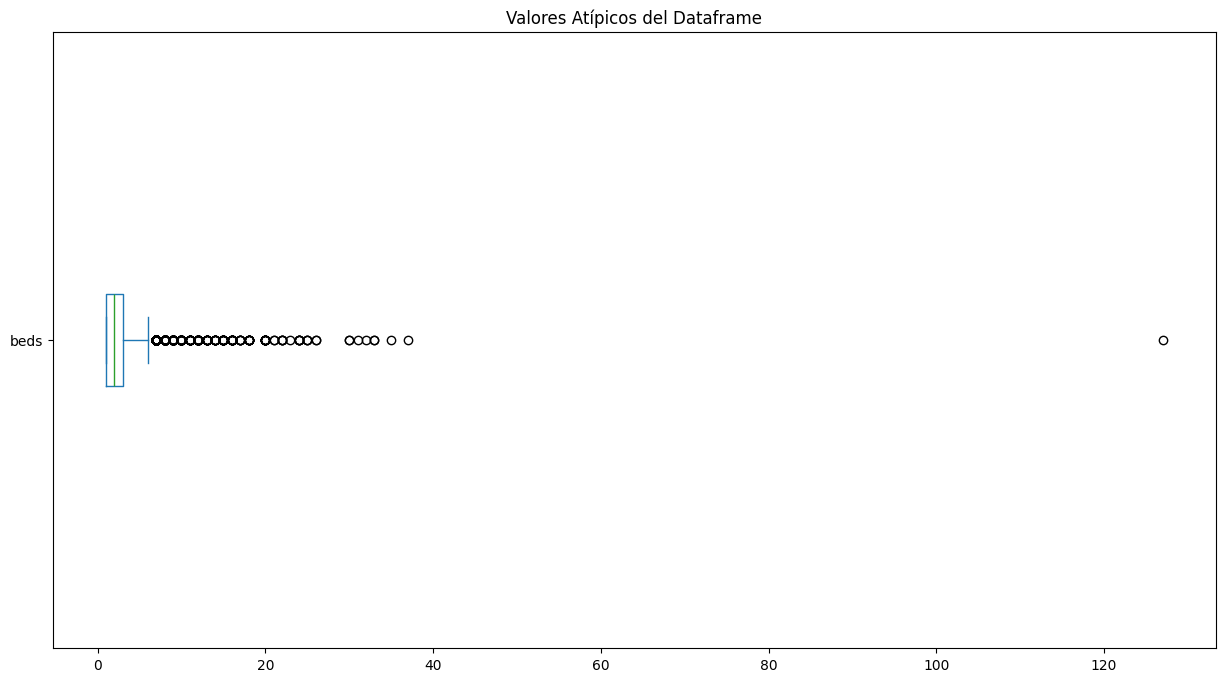

In [63]:
fig = plt.figure(figsize =(15, 8))
cuantitativas["beds"].plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [64]:
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido hosts_time_as_user_years             21.000
hosts_time_as_host_years             21.500
host_listings_count                 148.000
accommodates                          9.500
bathrooms                             3.500
bedrooms                              3.500
beds                                  6.000
reviews_per_month                     4.670
price                               518.315
minimum_nights                       76.000
maximum_nights                     2317.500
maximum_maximum_nights             2317.500
minimum_nights_avg_ntm               74.500
maximum_nights_avg_ntm             2179.500
availability_30                      42.500
availability_60                      96.000
availability_90                     145.500
availability_365                    623.500
number_of_reviews                   191.000
number_of_reviews_ltm                50.000
number_of_reviews_l30d                5.000
number_of_reviews_ly                 42.500
estima

In [65]:
data2_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data2_iqr

,hosts_time_as_user_years,hosts_time_as_host_years,host_listings_count,accommodates,bathrooms,bedrooms,beds,reviews_per_month,price,minimum_nights,...,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count
0,16.0,15.0,31.0,8.0,2.0,3.0,5.0,0.37,409.00,1.0,...,54,22086.0,4.41,4.47,4.59,4.66,4.64,4.83,4.38,20.0
1,16.0,15.0,5.0,5.0,2.0,3.0,4.0,0.53,388.00,2.0,...,66,25608.0,4.84,4.95,4.91,4.94,4.99,4.69,4.71,1.0
2,16.0,15.0,3.0,9.0,3.0,NaN,6.0,1.59,397.13,1.0,...,222,NaN,4.59,4.64,4.68,4.72,4.75,4.65,4.48,2.0
3,15.0,15.0,1.0,1.0,1.0,2.0,2.0,0.60,43.24,31.0,...,0,0.0,4.79,4.88,4.71,4.93,4.92,4.92,4.82,1.0
4,15.0,15.0,5.0,4.0,1.0,1.0,2.0,2.46,226.13,1.0,...,255,57663.0,4.56,4.62,4.59,4.85,4.86,4.91,4.52,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15288,9.0,9.0,27.0,2.0,1.0,2.0,1.0,0.00,93.87,32.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15289,9.0,9.0,27.0,2.0,1.0,2.0,1.0,0.00,93.87,32.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15290,14.0,14.0,NaN,4.0,1.0,2.0,3.0,0.00,183.00,1.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,NaN
15291,14.0,14.0,NaN,4.0,1.0,2.0,3.0,0.00,263.00,1.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,NaN


In [66]:
valores_nulos = data2_iqr.isnull().sum()
valores_nulos

hosts_time_as_user_years             0
hosts_time_as_host_years             0
host_listings_count               2688
accommodates                       440
bathrooms                          352
bedrooms                          1227
beds                               583
reviews_per_month                  587
price                              745
minimum_nights                      83
maximum_nights                       0
maximum_maximum_nights               0
minimum_nights_avg_ntm             217
maximum_nights_avg_ntm               0
availability_30                      0
availability_60                      0
availability_90                      0
availability_365                     0
number_of_reviews                 1690
number_of_reviews_ltm              846
number_of_reviews_l30d             476
number_of_reviews_ly              1250
estimated_occupancy_l365d            0
estimated_revenue_l365d            702
review_scores_rating              1163
review_scores_accuracy   

In [67]:
data3_iqr=data2_iqr.copy()
data3_iqr=data3_iqr.fillna(round(data2_iqr.median(),1))
data3_iqr

,hosts_time_as_user_years,hosts_time_as_host_years,host_listings_count,accommodates,bathrooms,bedrooms,beds,reviews_per_month,price,minimum_nights,...,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count
0,16.0,15.0,31.0,8.0,2.0,3.0,5.0,0.37,409.00,1.0,...,54,22086.0,4.41,4.47,4.59,4.66,4.64,4.83,4.38,20.0
1,16.0,15.0,5.0,5.0,2.0,3.0,4.0,0.53,388.00,2.0,...,66,25608.0,4.84,4.95,4.91,4.94,4.99,4.69,4.71,1.0
2,16.0,15.0,3.0,9.0,3.0,2.0,6.0,1.59,397.13,1.0,...,222,4900.0,4.59,4.64,4.68,4.72,4.75,4.65,4.48,2.0
3,15.0,15.0,1.0,1.0,1.0,2.0,2.0,0.60,43.24,31.0,...,0,0.0,4.79,4.88,4.71,4.93,4.92,4.92,4.82,1.0
4,15.0,15.0,5.0,4.0,1.0,1.0,2.0,2.46,226.13,1.0,...,255,57663.0,4.56,4.62,4.59,4.85,4.86,4.91,4.52,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15288,9.0,9.0,27.0,2.0,1.0,2.0,1.0,0.00,93.87,32.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15289,9.0,9.0,27.0,2.0,1.0,2.0,1.0,0.00,93.87,32.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15290,14.0,14.0,7.0,4.0,1.0,2.0,3.0,0.00,183.00,1.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,6.0
15291,14.0,14.0,7.0,4.0,1.0,2.0,3.0,0.00,263.00,1.0,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,6.0


In [69]:
valores_nulos = data3_iqr.isnull().sum()
valores_nulos

hosts_time_as_user_years          0
hosts_time_as_host_years          0
host_listings_count               0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
reviews_per_month                 0
price                             0
minimum_nights                    0
maximum_nights                    0
maximum_maximum_nights            0
minimum_nights_avg_ntm            0
maximum_nights_avg_ntm            0
availability_30                   0
availability_60                   0
availability_90                   0
availability_365                  0
number_of_reviews                 0
number_of_reviews_ltm             0
number_of_reviews_l30d            0
number_of_reviews_ly              0
estimated_occupancy_l365d         0
estimated_revenue_l365d           0
review_scores_rating              0
review_scores_accuracy            0
review_scores_cleanliness         0
review_scores_checkin       

In [68]:
barcelona_limpios = pd.concat([cualitativas,data3_iqr], axis=1)
barcelona_limpios

,name,host_id,host_name,host_location,latitude,longitude,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count
0,Huge flat for 8 people close to Sagrada Familia,71615,Maria Y Mireia Barcelona4Seasons,"Barcelona, Spain",41.405560,2.172620,f,t,t,la Sagrada Família,...,54,22086.0,4.41,4.47,4.59,4.66,4.64,4.83,4.38,20.0
1,CCIB Forum· Large Balcony · 5 min walk to CCIB,90417,Marnie,"Catalonia, Spain",41.412432,2.219750,t,t,t,el Besòs i el Maresme,...,66,25608.0,4.84,4.95,4.91,4.94,4.99,4.69,4.71,1.0
2,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163,Andres,"Barcelona, Spain",41.379780,2.176230,t,t,t,el Barri Gòtic,...,222,4900.0,4.59,4.64,4.68,4.72,4.75,4.65,4.48,2.0
3,In front of the beach,158596,Ester,"Barcelona, Spain",41.380370,2.192720,f,t,t,la Barceloneta,...,0,0.0,4.79,4.88,4.71,4.93,4.92,4.92,4.82,1.0
4,Architect's Loft near Gaudí & Passeig de Gràcia,177617,Joaquin,"Barcelona, Spain",41.396310,2.168320,t,t,t,la Dreta de l'Eixample,...,255,57663.0,4.56,4.62,4.59,4.85,4.86,4.91,4.52,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15288,Sagrada Familia View — Diagonal White Loft T5A...,114338664,Balcons De Barcelona,"Barcelona, Spain",41.401970,2.179467,t,t,t,la Sagrada Família,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15289,Sagrada Familia - Diagonal Industrial Loft T5A...,114338664,Balcons De Barcelona,"Barcelona, Spain",41.401970,2.179467,t,t,t,la Sagrada Família,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,27.0
15290,Cozy 2-Bedroom Apartment in Poble Sec for 4 pe...,1447144,Acomodis Apartments,"Barcelona, Spain",41.374546,2.163292,f,t,t,el Poble Sec,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,6.0
15291,Poble Sec - Lovely 2BR Apartment with Terrace,1447144,Acomodis Apartments,"Barcelona, Spain",41.374546,2.163292,f,t,t,el Poble Sec,...,0,0.0,4.73,4.78,4.76,4.85,4.86,4.85,4.57,6.0


In [70]:
valores_nulos = barcelona_limpios.isnull().sum()
valores_nulos

name                              0
host_id                           0
host_name                         0
host_location                     0
latitude                          0
longitude                         0
host_is_superhost                 0
host_has_profile_pic              0
host_identity_verified            0
neighbourhood_cleansed            0
neighbourhood_group_cleansed      0
property_type                     0
room_type                         0
amenities                         0
first_review                      0
last_review                       0
license                           0
hosts_time_as_user_years          0
hosts_time_as_host_years          0
host_listings_count               0
accommodates                      0
bathrooms                         0
bedrooms                          0
beds                              0
reviews_per_month                 0
price                             0
minimum_nights                    0
maximum_nights              

In [71]:
barcelona_limpios.to_csv("barcelona_limpios.csv")